# Explicit line form $y = mx + b$

$$
y = m x + b \qquad (m = \text{slope},\; b = \text{intercept})
$$

| Part | Implicit (original) | Explicit (this notebook) |
|---|---|---|
| Parameters | $(a, b, c)$ with $a^2+b^2=1$ | $(m, b)$ |
| Line through 2 points | normal vector of $p_2 - p_1$ | slope and intercept |
| Distance of a point | $\lvert ax + by + c \rvert$ | $\dfrac{\lvert m x - y + b \rvert}{\sqrt{m^2+1}}$ |
| Least-squares fit | SVD of centred points | linear system $A\,[m,\, b]^T = \mathbf{y}$ |
| Plotting | $y = (-ax - c)/b$ | $y = mx + b$ directly |

## Step 1 — Imports and synthetic data *(copied)*

In [9]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

def init_random(seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

def generate_data(N, p, direction, inlier_ratio=0.5):
    WIDTH, HEIGHT = 640, 480
    p = np.array(p, dtype=float)
    direction = np.array(direction, dtype=float)
    direction /= np.linalg.norm(direction)

    N_inlier = int(N * inlier_ratio)
    N_outlier = N - N_inlier

    points = []

    diag = np.sqrt(WIDTH**2 + HEIGHT**2)
    for _ in range(N_inlier):
        t = (random.random() * diag) - diag / 2.0
        q = p + t * direction
        q[0] += np.random.normal(0.0, 10.0)
        q[1] += np.random.normal(0.0, 10.0)
        points.append(q)

    for _ in range(N_outlier):
        points.append((random.random() * WIDTH, random.random() * HEIGHT))

    return np.array(points, dtype=float)

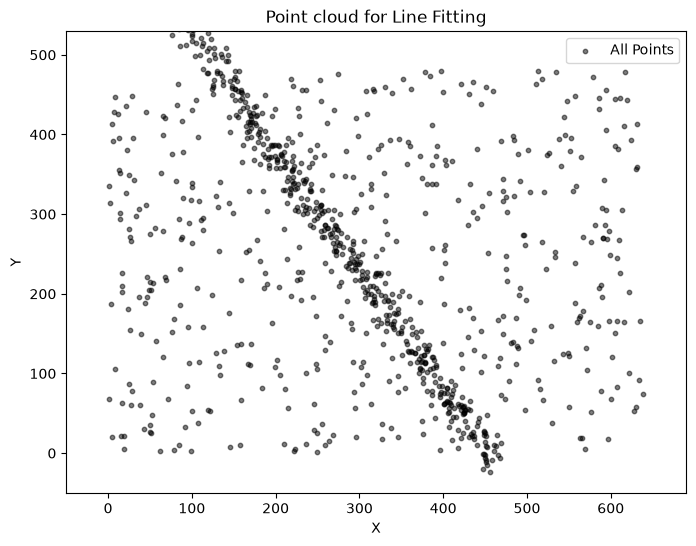

In [2]:
init_random(seed=0)

N = 1000
p = (240.0, 320.0)
alpha = random.random() * 2.0 * np.pi
dir_ = (np.cos(alpha), np.sin(alpha))
points = generate_data(N, p, dir_, inlier_ratio=0.5)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, c='k', alpha=0.5, label='All Points')
ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Point cloud for Line Fitting')
ax.legend()
plt.show()

## Step 2 — Line helpers in explicit form

### Line through two points
$$
m = \frac{y_2 - y_1}{x_2 - x_1}, \qquad b = y_1 - m x_1
$$

### Distance of a point to the line

$$
d = \frac{\lvert m x - y + b \rvert}{\sqrt{m^2 + 1}}
$$


In [ ]:
def fit_line_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    
    # Prevengo errori per la linea verticale che NON ha una pendenza finita
    if abs(x2 - x1) < 1e-8:      
        return None
    
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b

def distance_point_line(line_params, point):
    m, b = line_params
    x, y = point
    return abs(m*x - y + b) / math.sqrt(m**2 + 1)

In [4]:
def iteration_number(confidence, sample_size, inliers, N):
    if inliers == 0:
        return float('inf')
    ratio = inliers / float(N)
    top = math.log(1.0 - confidence)
    bottom = math.log(1.0 - ratio**sample_size)
    return math.ceil(top / bottom) if bottom != 0 else float('inf')

## Step 3 — RANSAC

The RANSAC loop does not care how the line is represented: it only calls `fit_line_two_points`
and `distance_point_line`. So it is identical to Notebook 1 (including the `while` loop fix).

In [5]:
def ransac_line(points, max_iterations=2000, sigma=10.0, confidence=0.95):
    best_inliers_count = 0
    best_line, best_inliers_list = None, []

    i = 0
    while i < max_iterations:
        i += 1
        idx1, idx2 = np.random.choice(len(points), 2, replace=False)
        line_params = fit_line_two_points(points[idx1], points[idx2])
        if line_params is None:
            continue

        inliers = [pt for pt in points if distance_point_line(line_params, pt) < sigma]

        if len(inliers) > best_inliers_count:
            best_inliers_count, best_line, best_inliers_list = len(inliers), line_params, inliers
            max_iterations = min(max_iterations, iteration_number(confidence, 2, best_inliers_count, len(points)))

    print(f"RANSAC stopped after {i} iterations")
    return best_line, np.array(best_inliers_list)

## Step 4 — Over-determined solution in explicit form

Every inlier gives one equation that is **linear** in the unknowns $m$ and $b$:

$$
m x_i + b = y_i, \qquad i = 1, \dots, n
$$

In matrix form:

$$
\underbrace{\begin{bmatrix} x_1 & 1 \\ x_2 & 1 \\ \vdots & \vdots \\ x_n & 1 \end{bmatrix}}_{A}
\begin{bmatrix} m \\ b \end{bmatrix}
=
\underbrace{\begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}}_{\mathbf{y}}
$$

$n$ equations, 2 unknowns → over-determined. The least-squares solution is
$\begin{bmatrix} m \\ b \end{bmatrix} = (A^T A)^{-1} A^T \mathbf{y}$

In [10]:
def fit_line_least_squares(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.column_stack([x, np.ones(len(x))])    # one row per inlier: [x_i, 1]
    
    # Compute the least squares solution
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return m, b

## Step 5 — Run RANSAC, then refine with all inliers

A nice advantage of the explicit form: the parameters are easy to interpret, so we can compare them
directly with the true line. The true line goes through `p` with direction `dir_`, so
$m_{true} = d_y / d_x$ and $b_{true} = p_y - m_{true}\,p_x$.

In [11]:
ransac_line_params, inliers = ransac_line(points)
refined_line = fit_line_least_squares(inliers)

m_true = dir_[1] / dir_[0]
b_true = p[1] - m_true * p[0]

print(f"Number of inliers: {len(inliers)} out of {len(points)}")
print(f"True line:                  m={m_true:.3f}, b={b_true:.2f}")
print("RANSAC line  (2 points):    m={:.3f}, b={:.2f}".format(*ransac_line_params))
print("Refined line (all inliers): m={:.3f}, b={:.2f}".format(*refined_line))

RANSAC stopped after 28 iterations
Number of inliers: 323 out of 1000
True line:                  m=-1.483, b=675.92
RANSAC line  (2 points):    m=-1.517, b=675.84
Refined line (all inliers): m=-1.509, b=675.45


## Step 6 — Results

Drawing is now simpler: $y = mx + b$ can be evaluated directly.

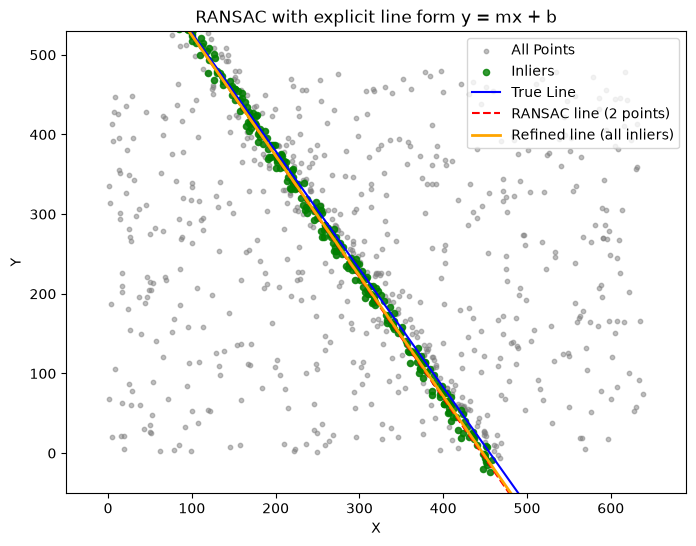

In [12]:
def draw_line(ax, line_params, **kwargs):
    m, b = line_params
    x_vals = np.linspace(0, 640, 2)
    ax.plot(x_vals, m*x_vals + b, **kwargs)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(points[:, 0], points[:, 1], s=10, c='gray', alpha=0.5, label='All Points')
ax.scatter(inliers[:, 0], inliers[:, 1], s=20, c='green', alpha=0.8, label='Inliers')

draw_line(ax, (m_true, b_true), c='blue', label='True Line')
draw_line(ax, ransac_line_params, c='red', ls='--', label='RANSAC line (2 points)')
draw_line(ax, refined_line, c='orange', lw=2, label='Refined line (all inliers)')

ax.set_xlim([-50, 690])
ax.set_ylim([-50, 530])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('RANSAC with explicit line form y = mx + b')
ax.legend()
plt.show()

## Conclusion

* **Pros of the explicit form:** only 2 parameters -> the least-squares fit is a plain linear system;

* **Cons:** vertical lines cannot be represented -> implicit form is more genera;